# mlr_investigation_friant.ipynb

In [1]:
import xarray as xr
import os 
import rioxarray
from pyproj import CRS, Transformer
import sys
import subprocess
import numpy as np
import pandas as pd
from pathlib import Path
import geopandas as gpd
from rasterio.enums import Resampling
from typing import List, Dict, Tuple, Optional
from datetime import datetime
import time
import importlib

In [2]:
sys.path.insert(1, '/home/rossamower/bin/scripts/')

In [3]:
import metadata as metadata
import plotting as plotting
import preprocessing as preprocessing
import lm_model as lm_model
import postprocessing as postprocessing

In [4]:
importlib.reload(metadata)
importlib.reload(plotting)
importlib.reload(preprocessing)
importlib.reload(lm_model)
importlib.reload(postprocessing)

<module 'postprocessing' from '/home/rossamower/bin/scripts/postprocessing.py'>

# Inputs

In [5]:
aso_site_name = 'USCASJ'

## Metadata

In [6]:
def load_aso_metadata(aso_site_name: str,
                  config_dir: str = '/home/rossamower/work/aso/configs/',
                 ):
    cfg = metadata.load_yaml(Path(f"{config_dir}regions/{aso_site_name}.yaml"))
    elev_bin_edges_m, elev_bin_labels = metadata.get_elevation_bins(cfg)
    start_wy = int(cfg["aso_years"]["start"])
    end_wy = int(cfg["aso_years"]["end"])
    shape_fpath = cfg["data_filepaths"]["aso_shape"]
    demBin_fpath = cfg["data_filepaths"]["aso_demBin"]
    aso_spatial_fpath = cfg["data_filepaths"]["aso_spatial"]
    aso_tseries_fpath = cfg["data_filepaths"]["aso_temporal"]
    uaswe_dir = cfg["data_filepaths"]["uaswe_dir"]
    snowmodel_dir = cfg["data_filepaths"]["snowmodel_dir"]
    snodas_dir = cfg["data_filepaths"]["snodas_dir"]
    insitu_dir = cfg["data_filepaths"]["insitu_dir"]
    mlrPred_dir = cfg["data_filepaths"]["mlrPred_dir"]
    if not os.path.exists(mlrPred_dir): os.makedirs(mlrPred_dir)
    shape_crs = f'EPSG:{cfg["crs"]["epsg"]}'
    return elev_bin_labels, shape_fpath, demBin_fpath, aso_spatial_fpath, aso_tseries_fpath, snowmodel_dir, snodas_dir, insitu_dir, mlrPred_dir, uaswe_dir, shape_crs, cfg

## Load ASO

In [7]:
def load_aso_data(aso_spatial_fpath: str,
                  aso_tseries_fpath: str,
                  demBin_fpath: str,
                  shape_fpath: str,
                  shape_crs: str,
                 ):
    aso_spatial_ds = xr.open_dataset(aso_spatial_fpath,engine ='netcdf4')
    aso_demBin_ds = xr.open_dataset(demBin_fpath,engine ='netcdf4')
    aso_tseries_ds = xr.open_dataset(aso_tseries_fpath,engine ='netcdf4')
    shape_geog_gdf = gpd.read_file(shape_fpath)
    shape_proj_gdf = shape_geog_gdf.to_crs(shape_crs)

    return aso_spatial_ds, aso_demBin_ds, shape_proj_gdf, aso_tseries_ds

## Misc

In [8]:
def pad_zero(val_str):
    if len(val_str) ==1:
        return '0' + val_str
    else:
        return val_str

def dataset_to_list(ds: xr.Dataset) -> list:
    da_list = []
    for pil in ds.data_vars:
        da = ds[pil]
        da.name = pil
        da_list.append(da)
    return da_list

def snowmodel_swe_fpaths(base_dir,water_yrs,var):
    nc_lst = []
    for wy in water_yrs:
        nc_dir = f'{base_dir}wy_{wy}/netcdf/'
        for file in os.listdir(nc_dir):
            if var in file:
                nc_lst.append(nc_dir + file)
    return sorted(nc_lst)

def timing_vars(obs_data_test_ds: xr.Dataset):
    date_str = str(obs_data_test_ds.time.values[-1])[0:10]
    year_str = date_str[0:4]
    month_str = date_str[5:7]
    day_str = date_str[8:10]
    
    if int(month_str) >= 10:
        wy_str = str(int(year_str) +1)
    else:
        wy_str = year_str
    return year_str, month_str, day_str, wy_str

def get_default_settings():
    user_elevation_interval = -1
    model_num = 0   
    isMean = False
    isCombination = True
    prediction_mm_df = None
    prediction_acreFt_df = None
    prediction_pillow_df = None
    isCombination = True
    user_qa_level = 0
    QA_flag = user_qa_level + 1
    elev_band = user_elevation_interval
    return model_num,isMean,isCombination,prediction_mm_df,prediction_acreFt_df,prediction_pillow_df,user_qa_level,elev_band, QA_flag

# Preprocessing

## Default Settings

In [9]:
model_num,isMean,isCombination,prediction_mm_df,prediction_acreFt_df,prediction_pillow_df,user_qa_level,elev_band, QA_flag = get_default_settings()

## Load Metadata

In [10]:
# load metadata information.
elev_bin_labels, shape_fpath, demBin_fpath, aso_spatial_fpath, aso_tseries_fpath, snowmodel_dir, snodas_dir, insitu_dir, mlrPred_dir,uaswe_dir,shape_crs,cfg = load_aso_metadata(aso_site_name)

# pillows to exclude from QA.
exclude_pillows = cfg['pillow_api']['exclude_pillows']
elev_bin_edges_m, elev_bin_labels = metadata.get_elevation_bins(cfg)
start_wy = int(cfg["aso_years"]["start"])
end_wy = int(cfg["aso_years"]["end"])

# Load Input Data

In [11]:
# load spatial data.
aso_spatial_ds, dem_bin, shape_proj_gdf, aso_tseries_ds = load_aso_data(aso_spatial_fpath,
                                                                                aso_tseries_fpath,
                                                                                demBin_fpath,
                                                                                shape_fpath,
                                                                                shape_crs)

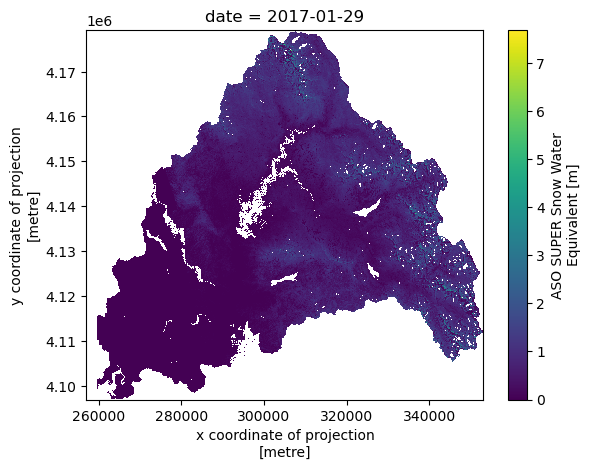

In [12]:
aso_spatial_ds.aso_swe[0].plot()

In [13]:
import rioxarray as rxr
aso_flight = rxr.open_rasterio('/home/rossamower/work/aso/data/aso/USCASJ/wy_2026/raw/ASO_SanJoaquin_2026Mar28-29_swe_50m.tif').squeeze(drop = True).rio.write_crs(shape_crs)

aso_flight

<xarray.DataArray (y: 1657, x: 1931)> Size: 13MB
[3199667 values with dtype=float32]
Coordinates:
  * x            (x) float64 15kB 2.568e+05 2.568e+05 ... 3.532e+05 3.533e+05
  * y            (y) float64 13kB 4.18e+06 4.179e+06 ... 4.097e+06 4.097e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     nan
    scale_factor:   1.0
    add_offset:     0.0

In [20]:
aso_flight_clp = aso_flight.rio.clip(shape_proj_gdf.geometry)
aso_flight_clp.shape

(1648, 1922)

In [18]:
aso_spatial_ds.aso_swe.shape

(35, 1648, 1922)

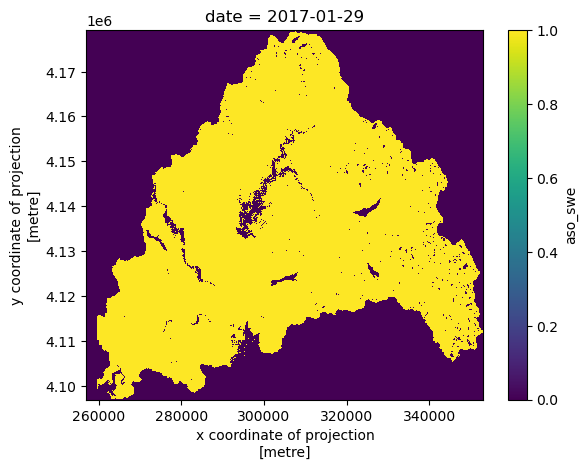

In [ ]:
aso_mask = (~aso_spatial_ds.aso_swe[0].isnull()).values
aso_mask.plot()

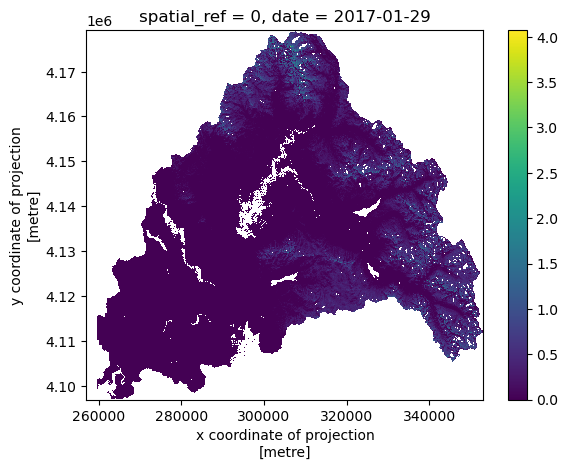

In [ ]:
aso_flight_clp.where(aso_mask).plot()

In [28]:
aso_flight_filled = aso_flight_clp.where(aso_mask).drop('date')
aso_flight_filled

<xarray.DataArray (y: 1648, x: 1922)> Size: 13MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * x            (x) float64 15kB 2.57e+05 2.571e+05 ... 3.53e+05 3.531e+05
  * y            (y) float64 13kB 4.179e+06 4.179e+06 ... 4.097e+06 4.097e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     nan

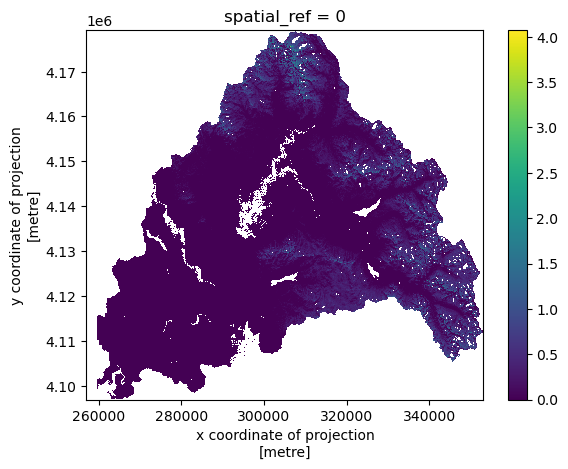

In [29]:
aso_flight_filled.plot()

In [ ]:
aso_dir_processed = '/home/rossamower/work/aso/data/aso/USCASJ/wy_2026/raw/'
save_fname = 'ASO_50M_SWE_USCASJ_20260328.tif'
save_path = f'{aso_dir_processed}{save_fname}'


aso_flight_filled.rio.to_raster(save_path)